##Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.stats import skew, kurtosis
import os
import warnings

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Data Preprocessing

In [3]:
DATA_DIR = '/content/drive/My Drive/Formative Datasets/HMM data'
ACTIVITIES = ['Standing', 'Walking', 'Jumping', 'Still']


# Function to load a single recording
def load_recording(activity, recording_folder):

    base_path = f'{DATA_DIR}/{activity}/{recording_folder}'

    files = os.listdir(base_path)

    accel_file = None
    gyro_file = None

    # Automatically detect files
    for f in files:
        name = f.lower()

        if "acc" in name:
            accel_file = f

        elif "gyro" in name:
            gyro_file = f

    if accel_file is None or gyro_file is None:
        raise Exception("Accelerometer or Gyroscope file missing")

    accel_path = f'{base_path}/{accel_file}'
    gyro_path = f'{base_path}/{gyro_file}'

    accel_df = pd.read_csv(accel_path)
    gyro_df = pd.read_csv(gyro_path)

    # Rename columns depending on sensor logger format
    accel_df.columns = ['time', 'seconds_elapsed', 'accel_x', 'accel_y', 'accel_z']
    gyro_df.columns = ['time', 'seconds_elapsed', 'gyro_x', 'gyro_y', 'gyro_z']

    # Merge both sensors
    merged_df = pd.merge_asof(
    accel_df.sort_values("seconds_elapsed"),
    gyro_df.sort_values("seconds_elapsed"),
    on="seconds_elapsed"
)

    merged_df['activity'] = activity
    merged_df['recording'] = recording_folder

    return merged_df

This function load_recording() loads a single activity recording from the dataset. It automatically finds the accelerometer and gyroscope CSV files in the folder, reads them into pandas DataFrames, and renames the columns for consistency.

The function then merges the two sensor signals based on the closest timestamps so that each row contains both accelerometer and gyroscope data.

Finally, it adds two columns: activity to indicate the type of activity (standing, walking, jumping, or still) and recording to identify the recording folder.

In [4]:
# Function to load all data
def load_all_data():

    all_data = []

    for activity in ACTIVITIES:

        activity_path = f'{DATA_DIR}/{activity}'

        recordings = [
            d for d in os.listdir(activity_path)
            if os.path.isdir(f'{activity_path}/{d}')
        ]

        print(f"\nLoading {activity}: {len(recordings)} recordings")

        for rec in recordings:

            try:

                df = load_recording(activity, rec)

                all_data.append(df)

                print(f" ✓ {rec}: {len(df)} samples")

            except Exception as e:

                print(f" ✗ Error loading {rec}: {e}")

    combined_df = pd.concat(all_data, ignore_index=True)

    return combined_df

    # Load dataset
df_all = load_all_data()


Loading Standing: 12 recordings
 ✓ standing1-2026-03-03_16-42-38 (Unzipped Files): 691 samples
 ✓ standing6-2026-03-06_11-26-26 (Unzipped Files): 663 samples
 ✓ standing4-2026-03-06_11-26-09 (Unzipped Files): 657 samples
 ✓ standing5-2026-03-06_11-26-17 (Unzipped Files): 667 samples
 ✓ standing3-2026-03-06_11-26-01 (Unzipped Files): 672 samples
 ✓ standing2-2026-03-03_16-42-38 (Unzipped Files): 691 samples
 ✓ Standing_7-2026-03-05_14-34-45: 597 samples
 ✓ Standing_8-2026-03-05_14-34-57: 616 samples
 ✓ Standing_9-2026-03-05_14-35-09: 591 samples
 ✓ Standing_10-2026-03-05_14-35-33: 586 samples
 ✓ Standing_11-2026-03-05_14-35-51: 599 samples
 ✓ Standing_12-2026-03-05_14-35-21: 589 samples

Loading Walking: 12 recordings
 ✓ walking6-2026-03-06_11-30-28 (Unzipped Files): 720 samples
 ✓ walking5-2026-03-06_11-30-17 (Unzipped Files): 679 samples
 ✓ walking4-2026-03-06_11-30-09 (Unzipped Files): 674 samples
 ✓ walking3-2026-03-06_11-30-01 (Unzipped Files): 697 samples
 ✓ walking2-2026-03-06_1

The load_all_data() function loads all recordings for every activity in the dataset.

For each activity (standing, walking, jumping, still), it lists all the folders containing recordings. It then uses the load_recording() function to load each individual recording and appends it to a list.

If a recording fails to load, it prints an error message but continues with the others. After all recordings are loaded, the function combines them into a single DataFrame with all sensor data from all recordings.

In [5]:
print("\nTotal samples loaded:", len(df_all))
print("Total recordings:", df_all.groupby(['activity','recording']).ngroups)


print("\nSamples per activity:")
print(df_all.groupby('activity').size())


Total samples loaded: 32053
Total recordings: 50

Samples per activity:
activity
Jumping     7806
Standing    7619
Still       8795
Walking     7833
dtype: int64


In [6]:
df_all.head()

,time_x,seconds_elapsed,accel_x,accel_y,accel_z,time_y,gyro_x,gyro_y,gyro_z,activity,recording
0,1772556159001715200,0.069715,-0.200848,0.246702,-0.036393,1.772556e+18,0.175653,0.040734,0.056460,Standing,standing1-2026-03-03_16-42-38 (Unzipped Files)
1,1772556159011707100,0.079707,-0.167947,0.270160,-0.057634,1.772556e+18,0.184535,0.031113,0.056369,Standing,standing1-2026-03-03_16-42-38 (Unzipped Files)
2,1772556159021700000,0.089700,-0.108262,0.297441,-0.092446,1.772556e+18,0.188751,0.023341,0.053785,Standing,standing1-2026-03-03_16-42-38 (Unzipped Files)
3,1772556159031692300,0.099692,-0.043288,0.304305,-0.082809,1.772556e+18,0.194122,0.015292,0.052974,Standing,standing1-2026-03-03_16-42-38 (Unzipped Files)
4,1772556159041685000,0.109685,-0.014445,0.311630,-0.089050,1.772556e+18,0.205512,0.006128,0.053041,Standing,standing1-2026-03-03_16-42-38 (Unzipped Files)


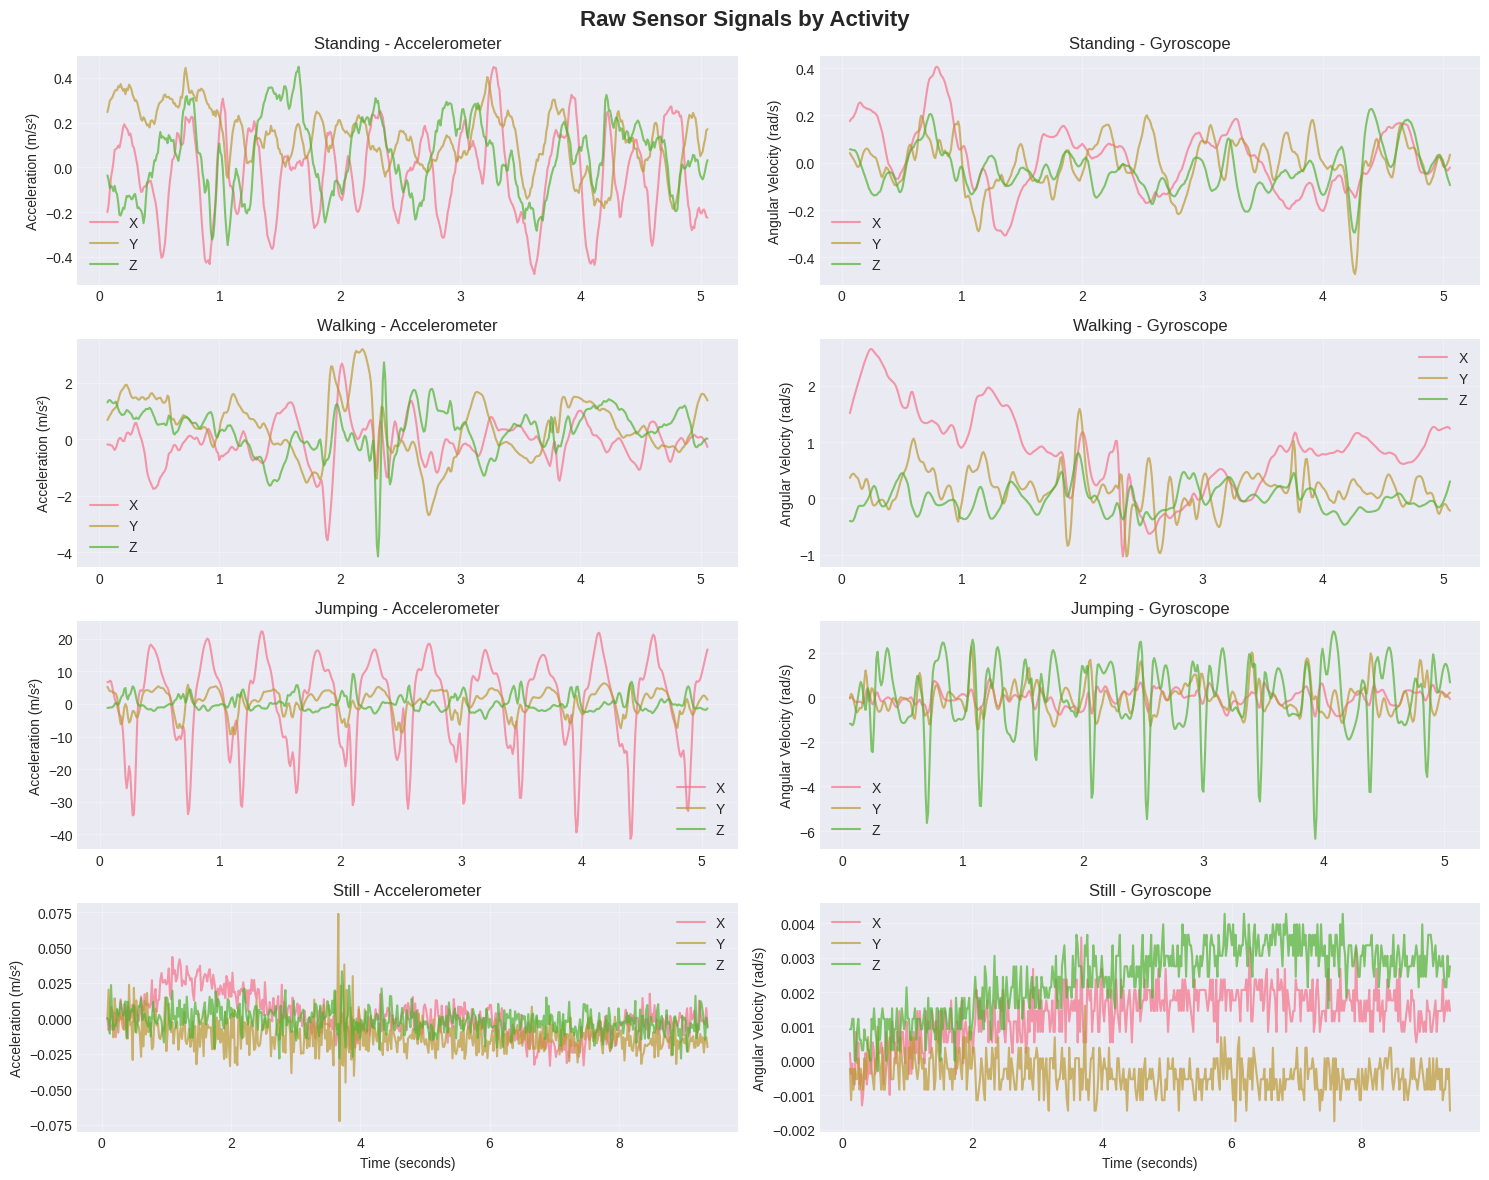

In [7]:
# Plot raw sensor data for each activity
fig, axes = plt.subplots(4, 2, figsize=(15, 12))
fig.suptitle('Raw Sensor Signals by Activity', fontsize=16, fontweight='bold')

for idx, activity in enumerate(ACTIVITIES):
    # Get first recording of this activity
    activity_data = df_all[df_all['activity'] == activity].head(500)

    # Plot accelerometer
    axes[idx, 0].plot(activity_data['seconds_elapsed'], activity_data['accel_x'], label='X', alpha=0.7)
    axes[idx, 0].plot(activity_data['seconds_elapsed'], activity_data['accel_y'], label='Y', alpha=0.7)
    axes[idx, 0].plot(activity_data['seconds_elapsed'], activity_data['accel_z'], label='Z', alpha=0.7)
    axes[idx, 0].set_title(f'{activity.capitalize()} - Accelerometer')
    axes[idx, 0].set_ylabel('Acceleration (m/s²)')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)

    # Plot gyroscope
    axes[idx, 1].plot(activity_data['seconds_elapsed'], activity_data['gyro_x'], label='X', alpha=0.7)
    axes[idx, 1].plot(activity_data['seconds_elapsed'], activity_data['gyro_y'], label='Y', alpha=0.7)
    axes[idx, 1].plot(activity_data['seconds_elapsed'], activity_data['gyro_z'], label='Z', alpha=0.7)
    axes[idx, 1].set_title(f'{activity.capitalize()} - Gyroscope')
    axes[idx, 1].set_ylabel('Angular Velocity (rad/s)')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

    if idx == 3:
        axes[idx, 0].set_xlabel('Time (seconds)')
        axes[idx, 1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

This code plots the raw sensor signals for each activity.

For each of the four activities (standing, walking, jumping, still), it selects the first 500 samples and creates two plots side by side: one for the accelerometer (X, Y, Z axes) and one for the gyroscope (X, Y, Z axes).

Each subplot shows how the sensor readings change over time, with gridlines and a legend for clarity. This visualization helps to see the differences in motion patterns between activities before feature extraction and modeling.

In [8]:
import numpy as np
from scipy.stats import skew, kurtosis

def safe_corr(a, b):
    """Compute correlation safely (avoid NaN if variance is zero)."""
    if np.std(a) == 0 or np.std(b) == 0:
        return 0
    return np.corrcoef(a, b)[0,1]


def safe_skew(data):
    if np.std(data) == 0:
        return 0
    return skew(data)


def safe_kurtosis(data):
    if np.std(data) == 0:
        return 0
    return kurtosis(data)


def extract_time_domain_features(window_data):
    """
    Extract time-domain features from a data window
    """
    features = {}

    axes = ['accel_x', 'accel_y', 'accel_z',
            'gyro_x', 'gyro_y', 'gyro_z']

    for axis in axes:

        data = window_data[axis].values

        features[f'{axis}_mean'] = np.mean(data)
        features[f'{axis}_std'] = np.std(data)
        features[f'{axis}_var'] = np.var(data)
        features[f'{axis}_min'] = np.min(data)
        features[f'{axis}_max'] = np.max(data)
        features[f'{axis}_range'] = np.max(data) - np.min(data)
        features[f'{axis}_median'] = np.median(data)

        # Safe statistical features
        features[f'{axis}_skew'] = safe_skew(data)
        features[f'{axis}_kurtosis'] = safe_kurtosis(data)

        # RMS
        features[f'{axis}_rms'] = np.sqrt(np.mean(data**2))


    # Signal Magnitude Area (SMA)

    sma_accel = (
        np.sum(np.abs(window_data['accel_x'])) +
        np.sum(np.abs(window_data['accel_y'])) +
        np.sum(np.abs(window_data['accel_z']))
    ) / len(window_data)

    sma_gyro = (
        np.sum(np.abs(window_data['gyro_x'])) +
        np.sum(np.abs(window_data['gyro_y'])) +
        np.sum(np.abs(window_data['gyro_z']))
    ) / len(window_data)

    features['sma_accel'] = sma_accel
    features['sma_gyro'] = sma_gyro


    # Safe correlations

    features['corr_accel_xy'] = safe_corr(window_data['accel_x'], window_data['accel_y'])
    features['corr_accel_xz'] = safe_corr(window_data['accel_x'], window_data['accel_z'])
    features['corr_accel_yz'] = safe_corr(window_data['accel_y'], window_data['accel_z'])

    return features

This function extract_time_domain_features() computes time-domain features from a window of sensor data (accelerometer and gyroscope).

For each axis (X, Y, Z), it calculates basic statistics like mean, standard deviation, variance, min, max, range, median, skewness, kurtosis, and RMS. It also computes Signal Magnitude Area (SMA) for accelerometer and gyroscope signals, which summarizes the overall motion magnitude.

Finally, it calculates the correlation between accelerometer axes using a safe function that avoids NaN values when the variance is zero. These features capture the characteristics of movement in the window and will be used as inputs for the Hidden Markov Model.

In [9]:
def extract_frequency_domain_features(window_data, sampling_rate=100):
    """
    Extract frequency-domain features using FFT
    """
    features = {}
    axes = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']

    for axis in axes:
        data = window_data[axis].values
        n = len(data)

        # Compute FFT
        fft_vals = fft(data)
        fft_magnitude = np.abs(fft_vals[:n//2])
        freqs = fftfreq(n, 1/sampling_rate)[:n//2]

        # Dominant frequency
        if len(fft_magnitude) > 0:
            dominant_freq_idx = np.argmax(fft_magnitude)
            features[f'{axis}_dominant_freq'] = freqs[dominant_freq_idx]

            # Spectral energy
            features[f'{axis}_spectral_energy'] = np.sum(fft_magnitude**2)

            # Spectral entropy
            psd = fft_magnitude**2
            psd_norm = psd / np.sum(psd)
            psd_norm = psd_norm[psd_norm > 0]  # Remove zeros for log
            features[f'{axis}_spectral_entropy'] = -np.sum(psd_norm * np.log2(psd_norm))
        else:
            features[f'{axis}_dominant_freq'] = 0
            features[f'{axis}_spectral_energy'] = 0
            features[f'{axis}_spectral_entropy'] = 0

    return features

The function extract_frequency_domain_features() computes frequency-domain features from a window of sensor data using the Fast Fourier Transform (FFT). For each axis (X, Y, Z of accelerometer and gyroscope), it calculates:

1. Dominant frequency – the frequency with the largest amplitude in the FFT, showing the main oscillation in the signal.

2. Spectral energy – the total power in the frequency spectrum, indicating the overall intensity of motion.

3. Spectral entropy – a measure of how uniform the energy is across frequencies; higher entropy means more complex or irregular motion.

The function ensures stability by setting all features to zero if the FFT has no data. These frequency-domain features complement the time-domain features and help the Hidden Markov Model distinguish activities based on motion patterns.

In [10]:
def create_windows(df, window_size=100, overlap=0.5):
    """
    Create sliding windows from the data
    window_size: number of samples per window
    overlap: fraction of overlap between windows
    """
    step_size = int(window_size * (1 - overlap))
    windows = []

    for activity in ACTIVITIES:
        activity_data = df[df['activity'] == activity]

        # Get unique recordings
        recordings = activity_data['recording'].unique()

        for rec in recordings:
            rec_data = activity_data[activity_data['recording'] == rec].reset_index(drop=True)

            # Create windows
            for i in range(0, len(rec_data) - window_size, step_size):
                window = rec_data.iloc[i:i+window_size]
                windows.append({
                    'data': window,
                    'activity': activity,
                    'recording': rec
                })

    return windows

The create_windows() function splits the sensor data into sliding windows, which are small segments of consecutive samples used for feature extraction.

*   Window_size specifies how many samples each window contains.
*   Overlap controls how much each window overlaps with the previous one (e.g., 0.5 means 50% overlap).

For each activity and each recording, the function slides a window across the data and stores it along with the corresponding activity label and recording ID. These windows are then used to compute features, ensuring that the HMM sees consistent, sequential chunks of sensor data rather than the raw, continuous stream.

In [11]:
def extract_features_from_windows(windows):
    """
    Extract all features from windows
    """
    feature_list = []

    print(f"Extracting features from {len(windows)} windows...")

    for idx, window_dict in enumerate(windows):
        window_data = window_dict['data']

        # Extract features
        time_features = extract_time_domain_features(window_data)
        freq_features = extract_frequency_domain_features(window_data)

        # Combine features
        all_features = {**time_features, **freq_features}
        all_features['activity'] = window_dict['activity']
        all_features['recording'] = window_dict['recording']

        feature_list.append(all_features)

        if (idx + 1) % 100 == 0:
            print(f"  Processed {idx + 1}/{len(windows)} windows")

    return pd.DataFrame(feature_list)

The function extract_features_from_windows() computes all features for each window of sensor data. For every window, it:

1. Extracts time-domain features (mean, standard deviation, RMS, correlations, etc.) using extract_time_domain_features().

2. Extracts frequency-domain features (dominant frequency, spectral energy, spectral entropy) using extract_frequency_domain_features().

3. Combines all features into a single dictionary and adds the activity label and recording ID.

4. Appends the result to a list, which is finally converted into a DataFrame.

This DataFrame contains a feature vector for every window, ready for scaling and training the Hidden Markov Model

In [12]:
# Create windows
print("Creating sliding windows...")
windows = create_windows(df_all, window_size=100, overlap=0.5)
print(f"Created {len(windows)} windows\n")

Creating sliding windows...
Created 563 windows



This code uses the create_windows() function to split the full dataset df_all into sliding windows of 100 samples each, with 50% overlap between consecutive windows. Each window will later be used to extract time-domain and frequency-domain features. From the output, we can see 563 windows were created in total.

In [13]:
# Extract features
features_df = extract_features_from_windows(windows)

print(f"\n✓ Feature extraction complete")
print(f"Feature matrix shape: {features_df.shape}")
print(f"Number of features: {features_df.shape[1] - 2}")

Extracting features from 563 windows...
  Processed 100/563 windows
  Processed 200/563 windows
  Processed 300/563 windows
  Processed 400/563 windows
  Processed 500/563 windows

✓ Feature extraction complete
Feature matrix shape: (563, 85)
Number of features: 83


This code extracts features from all the sliding windows using the extract_features_from_windows() function.

Each window is transformed into a feature vector containing both time-domain and frequency-domain features, along with the activity label and recording ID. The resulting DataFrame features_df is a feature matrix where each row represents a window and each column represents a feature.

In [14]:
# Display sample features
features_df.head()

,accel_x_mean,accel_x_std,accel_x_var,accel_x_min,accel_x_max,accel_x_range,accel_x_median,accel_x_skew,accel_x_kurtosis,accel_x_rms,...,gyro_x_spectral_energy,gyro_x_spectral_entropy,gyro_y_dominant_freq,gyro_y_spectral_energy,gyro_y_spectral_entropy,gyro_z_dominant_freq,gyro_z_spectral_energy,gyro_z_spectral_entropy,activity,recording
0,-0.025147,0.197515,0.039012,-0.433099,0.306929,0.740028,0.011364,-0.501917,-0.762868,0.199109,...,346.258340,1.216675,1.0,38.216567,3.217165,1.0,41.861756,2.179732,Standing,standing1-2026-03-03_16-42-38 (Unzipped Files)
1,-0.036113,0.199631,0.039852,-0.433099,0.306929,0.740028,-0.002596,-0.328556,-1.009614,0.202871,...,244.814888,0.733314,1.0,72.684456,2.076007,1.0,36.213851,1.738892,Standing,standing1-2026-03-03_16-42-38 (Unzipped Files)
2,-0.052211,0.144888,0.020992,-0.365229,0.206244,0.571474,-0.020443,-0.316325,-0.748105,0.154008,...,122.887812,1.240960,0.0,79.837401,2.115911,0.0,21.880996,2.380912,Standing,standing1-2026-03-03_16-42-38 (Unzipped Files)
3,-0.019098,0.142930,0.020429,-0.271319,0.252248,0.523567,-0.006544,0.134752,-0.899007,0.144200,...,49.109921,2.050844,3.0,40.336245,2.609099,0.0,30.922172,1.983228,Standing,standing1-2026-03-03_16-42-38 (Unzipped Files)
4,-0.009917,0.160374,0.025720,-0.316081,0.252248,0.568329,-0.004578,-0.106676,-1.138174,0.160681,...,48.618903,1.179476,2.0,66.497933,1.953239,0.0,65.526621,1.211513,Standing,standing1-2026-03-03_16-42-38 (Unzipped Files)


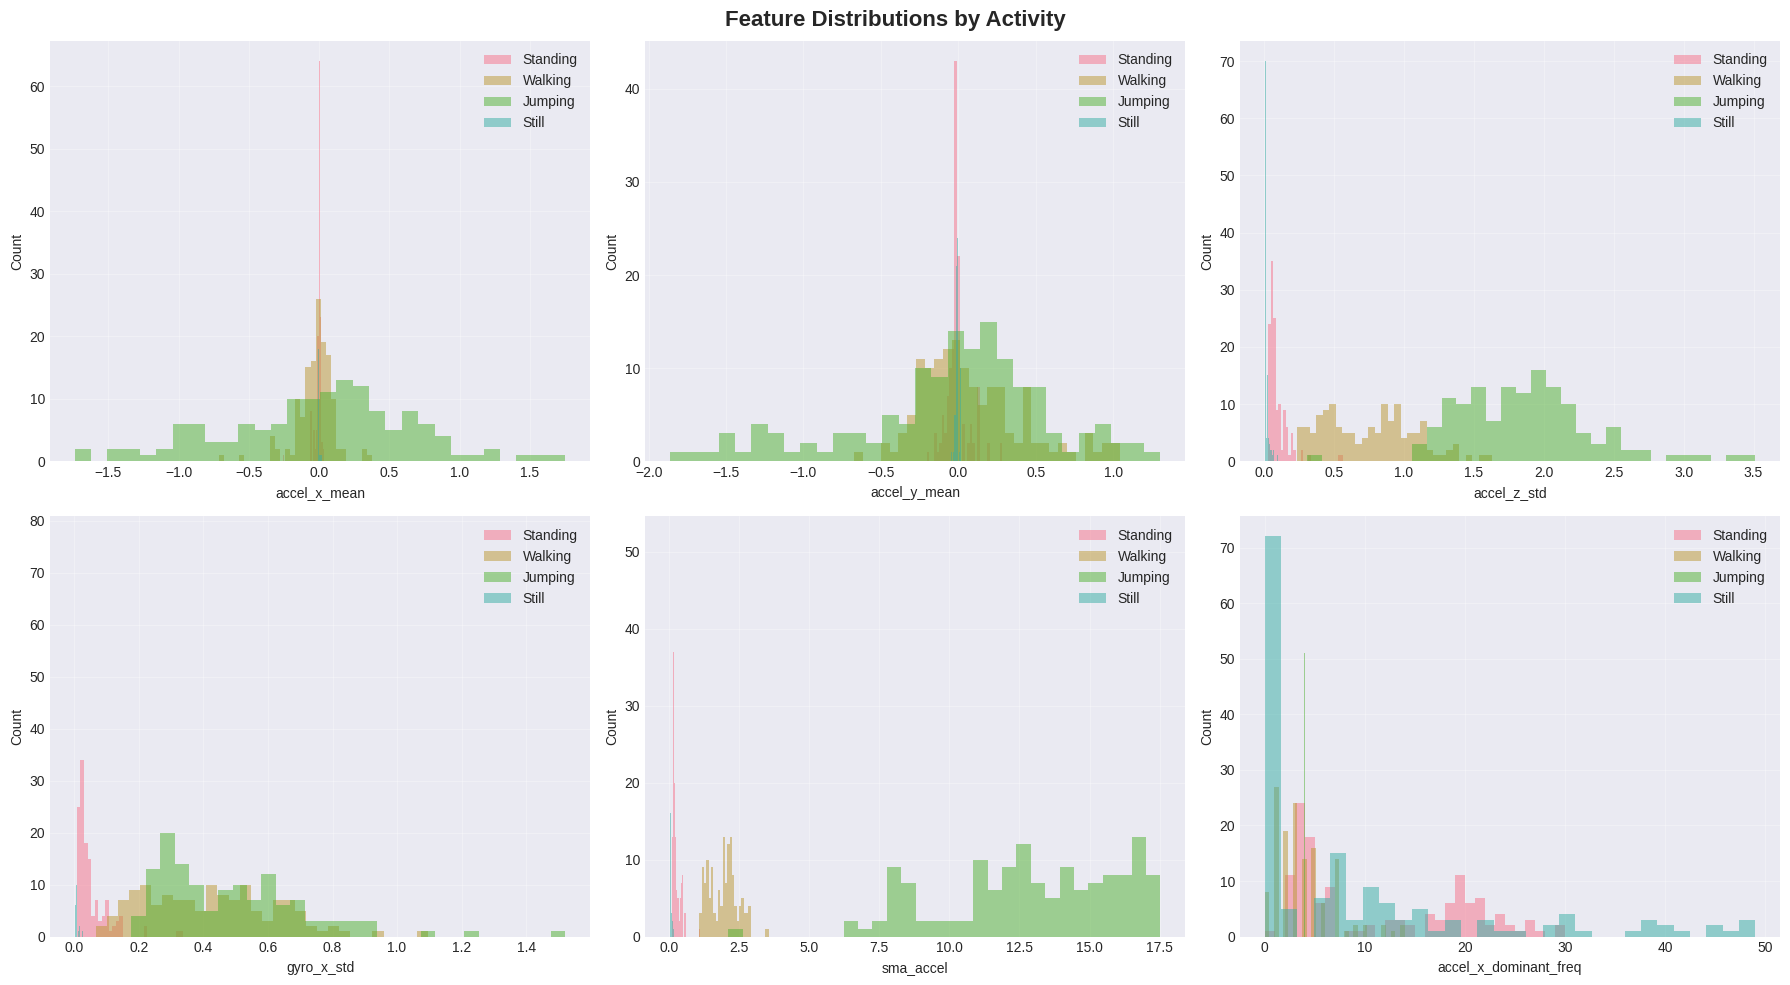

In [15]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Distributions by Activity', fontsize=16, fontweight='bold')

# Select some key features to visualize
key_features = ['accel_x_mean', 'accel_y_mean', 'accel_z_std',
                'gyro_x_std', 'sma_accel', 'accel_x_dominant_freq']

for idx, feature in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]

    for activity in ACTIVITIES:
        data = features_df[features_df['activity'] == activity][feature]
        ax.hist(data, alpha=0.5, label=activity, bins=30)

    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

This code visualizes the distribution of selected key features across activities.

For each chosen feature (e.g., mean or standard deviation of accelerometer/gyroscope axes, signal magnitude area, dominant frequency), it plots a histogram for each activity on the same axes.

Overlapping histograms allow us to see how well the features separate different activities, helping to understand which features are most useful for the Hidden Markov Model.

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Prepare features and labels
feature_columns = [col for col in features_df.columns if col not in ['activity', 'recording']]
X = features_df[feature_columns].values
y = features_df['activity'].values
recordings = features_df['recording'].values

# Replace NaN and inf values
X = np.nan_to_num(X)  # NaNs -> 0, inf -> large finite numbers

This code prepares the feature matrix X and labels y for model training. It selects all columns except activity and recording as features. Before scaling or training, it replaces any NaN values with 0 and infinite values with large finite numbers using np.nan_to_num(), ensuring the data is clean and safe for use.

In [17]:
# Encode activities as integers
activity_to_int = {activity: idx for idx, activity in enumerate(ACTIVITIES)}
int_to_activity = {idx: activity for activity, idx in activity_to_int.items()}
y_encoded = np.array([activity_to_int[activity] for activity in y])

print("Activity encoding:")
for activity, idx in activity_to_int.items():
    print(f"  {activity}: {idx}")

unique_recordings = features_df.groupby(['activity', 'recording']).size().reset_index()

Activity encoding:
  Standing: 0
  Walking: 1
  Jumping: 2
  Still: 3


This code converts the activity labels into integer values, which are easier for models like HMMs to handle.

Each activity (Standing, Walking, Jumping, Still) is assigned a unique integer, stored in activity_to_int. The inverse mapping int_to_activity allows converting integers back to activity names.

y_encoded contains the integer labels corresponding to each window’s features. Finally, unique_recordings lists all activity–recording combinations, which helps track data sources during training or evaluation.

In [18]:
# For each activity, use first 3 recordings for training, last for testing
train_indices = []
test_indices = []

for activity in ACTIVITIES:
    activity_indices = features_df[features_df['activity'] == activity].index.tolist()
    activity_recordings = features_df[features_df['activity'] == activity]['recording'].unique()

    # Use 75% for training, 25% for testing
    n_train_recs = max(1, int(len(activity_recordings) * 0.75))
    train_recs = activity_recordings[:n_train_recs]
    test_recs = activity_recordings[n_train_recs:]

    train_idx = features_df[(features_df['activity'] == activity) &
                            (features_df['recording'].isin(train_recs))].index.tolist()
    test_idx = features_df[(features_df['activity'] == activity) &
                           (features_df['recording'].isin(test_recs))].index.tolist()

    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

X_train = X[train_indices]
y_train = y_encoded[train_indices]
X_test = X[test_indices]
y_test = y_encoded[test_indices]

print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")


Training set: 426 samples
Test set: 137 samples


This code splits the dataset into training and testing sets based on recordings.

For each activity, approximately 75% of the recordings are used for training and the remaining 25% for testing. The corresponding feature indices are collected into train_indices and test_indices. Finally, the feature matrix X and encoded labels y_encoded are split into X_train, y_train, X_test, and y_test.

This ensures that training and testing data come from different recordings, which helps evaluate the model’s ability to generalize to unseen data.

In [19]:
# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Feature dimensions: {X_train_scaled.shape[1]}")

Feature dimensions: 83


This code normalizes the feature values using StandardScaler. It scales each feature to have a mean of 0 and a standard deviation of 1, which helps the Hidden Markov Model train more effectively. The scaler is fit on the training data and then applied to both training and test sets to ensure consistent scaling.

In [20]:
%pip install hmmlearn --break-system-packages -q

##Model Training

In [21]:
from hmmlearn import hmm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

N_STATES = len(ACTIVITIES)

model = hmm.GaussianHMM(
    n_components=N_STATES,
    covariance_type="diag",
    n_iter=100,
    tol=1e-4,
    random_state=42
)

This code initializes a Hidden Markov Model (HMM) using the hmmlearn library.

1. N_STATES is set to 4, corresponding to the four activities (Standing, Walking, Jumping, Still).

2. GaussianHMM is used because the observations (feature vectors) are continuous.

3. covariance_type="diag" assumes the features are uncorrelated within each state.

4. n_iter=100 and tol=1e-4 control the training convergence.

5. random_state=42 ensures reproducible results.

In [22]:
print("NaN values in feature matrix:", np.isnan(X).sum())

NaN values in feature matrix: 0


Ensures there are no missing values before training

In [24]:
# Fit the model
model.fit(X_train_scaled)

GaussianHMM(n_components=4, n_iter=100, random_state=42, tol=0.0001)

In [25]:
# Display model parameters
print("\nHMM Parameters:")
print(f"Number of states: {model.n_components}")
print(f"Number of features: {model.n_features}")
print(f"\nInitial state probabilities (π):")
print(model.startprob_)

print(f"\nTransition matrix (A):")
print(model.transmat_)


HMM Parameters:
Number of states: 4
Number of features: 83

Initial state probabilities (π):
[1. 0. 0. 0.]

Transition matrix (A):
[[0.94285688 0.01428578 0.03571445 0.00714289]
 [0.02272694 0.90909224 0.02272694 0.04545388]
 [0.02808989 0.         0.97191011 0.        ]
 [0.01587302 0.03174603 0.         0.95238095]]


This code displays the trained HMM’s parameters after fitting it to the training data.

1. Number of states: 4, corresponding to the four activities.

2. Number of features: 83, the size of each feature vector per window.

3. Initial state probabilities (π): [1. 0. 0. 0.] indicates the model starts in the first state with certainty.

4. Transition matrix (A): shows the probability of moving from one activity to another. For example, the first row indicates that if the model is in state 0, it stays there 94% of the time, or transitions to other states with smaller probabilities.

These parameters reflect the learned dynamics of activity transitions in my dataset. High diagonal values in the transition matrix suggest that each activity tends to persist for multiple windows, which matches real-world behavior.

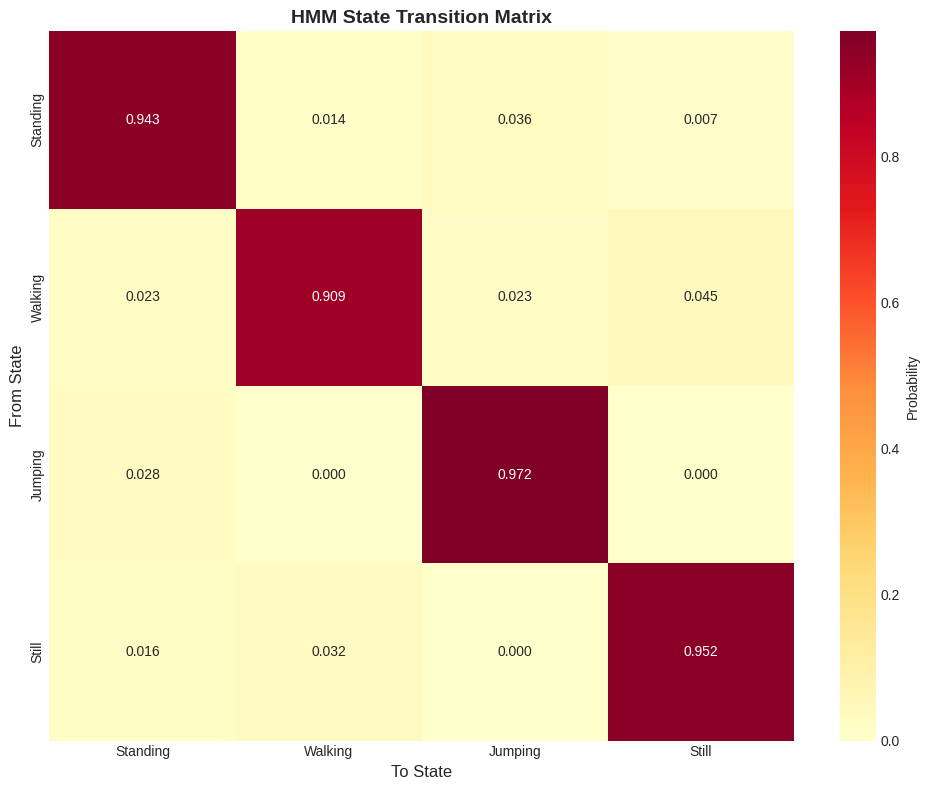

In [26]:
# Visualize transition matrix
plt.figure(figsize=(10, 8))
sns.heatmap(model.transmat_, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
            cbar_kws={'label': 'Probability'})
plt.title('HMM State Transition Matrix', fontsize=14, fontweight='bold')
plt.xlabel('To State', fontsize=12)
plt.ylabel('From State', fontsize=12)
plt.tight_layout()
plt.show()

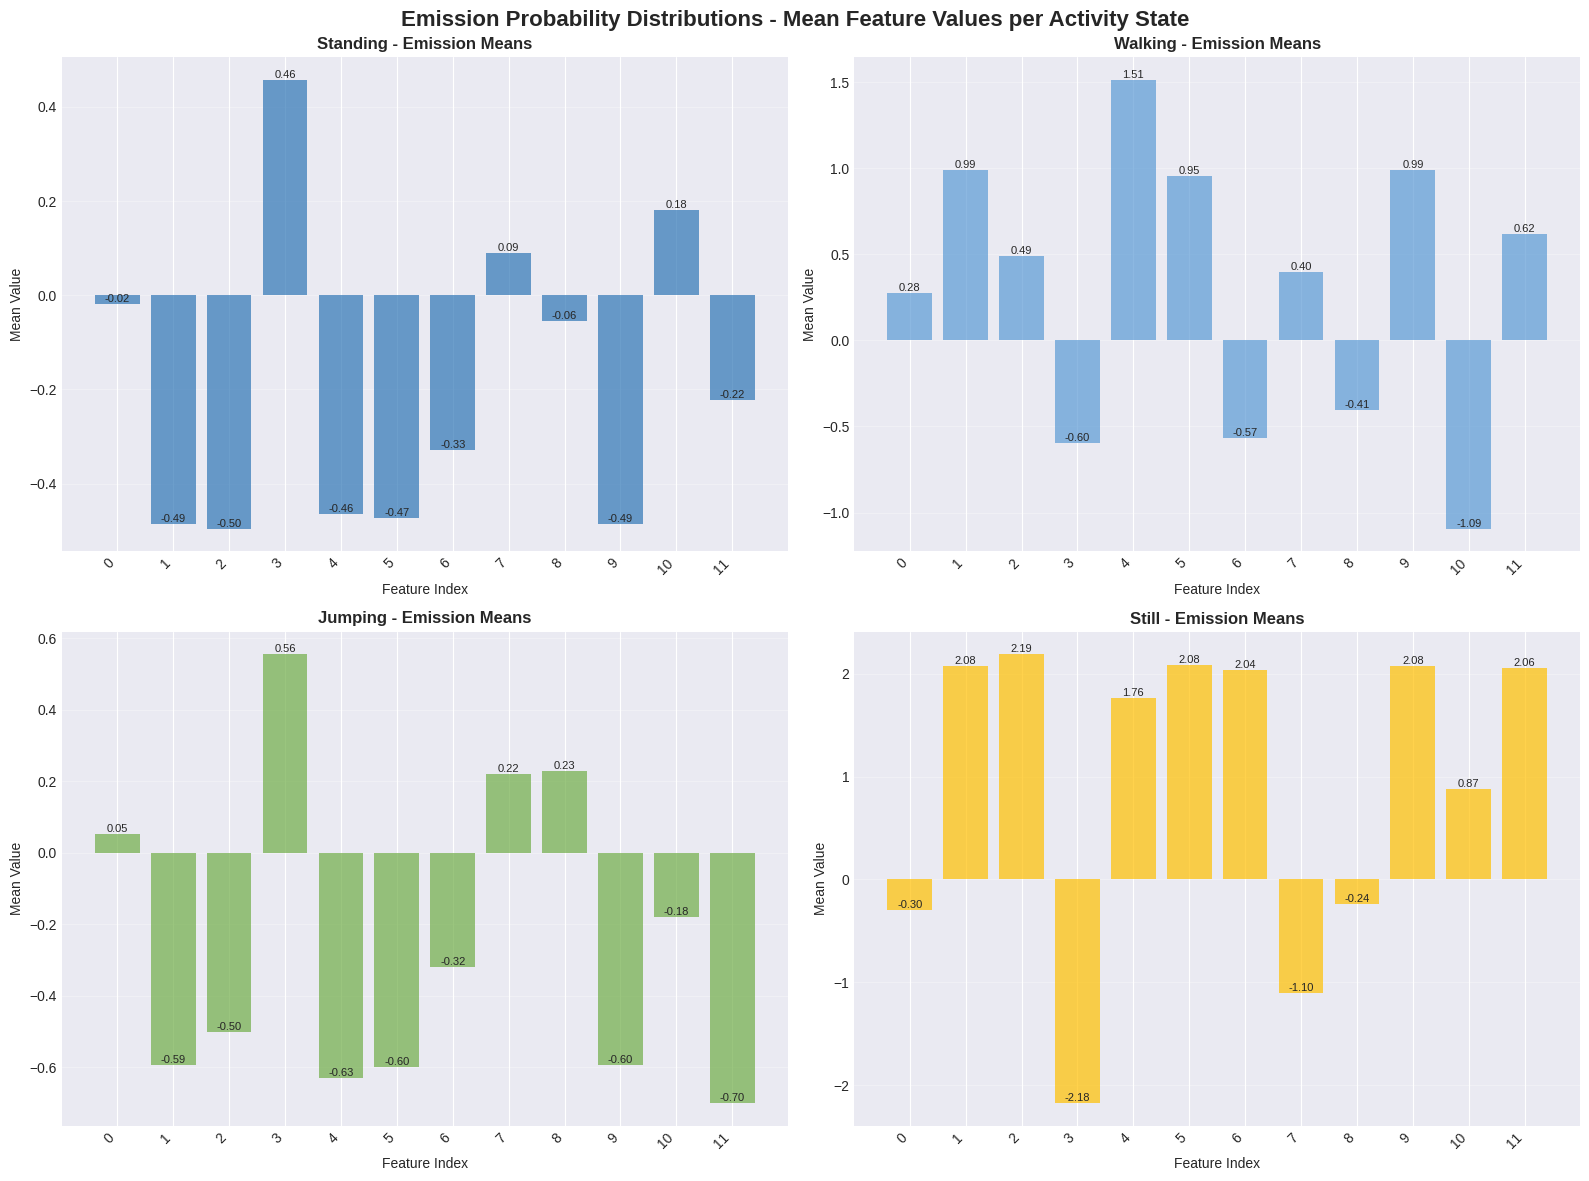

In [27]:
# Visualize Emission Probabilities (Mean feature values for each state)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Emission Probability Distributions - Mean Feature Values per Activity State',
             fontsize=16, fontweight='bold')

# Select a subset of features to visualize (first 12 features for clarity)
n_features_to_show = 12
feature_names = feature_columns[:n_features_to_show]

for idx, activity in enumerate(ACTIVITIES):
    ax = axes[idx // 2, idx % 2]

    # Get mean values for this state
    state_means = model.means_[idx][:n_features_to_show]

    # Create bar plot
    bars = ax.bar(range(n_features_to_show), state_means, alpha=0.7,
                   color=['#2E75B6', '#5B9BD5', '#70AD47', '#FFC000'][idx])

    ax.set_title(f'{activity.capitalize()} - Emission Means', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature Index', fontsize=10)
    ax.set_ylabel('Mean Value', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks(range(n_features_to_show))
    ax.set_xticklabels(range(n_features_to_show), rotation=45, ha='right')

    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


This code visualizes the emission probabilities of the trained HMM by plotting the mean feature values for each activity state.

For each activity (state), it selects the first 12 features for clarity.

A bar plot shows the mean value of each feature for that state, representing the model’s expected observation values when in that activity.

High or low mean values indicate which features are most characteristic of each activity, helping to interpret how the HMM distinguishes between activities.

In [28]:
print("\nEmission Probability Statistics:")
for idx, activity in enumerate(ACTIVITIES):
    print(f"\n{activity.capitalize()}:")
    print(f"  Mean feature value: {np.mean(model.means_[idx]):.4f}")
    print(f"  Std of means: {np.std(model.means_[idx]):.4f}")
    print(f"  Min feature mean: {np.min(model.means_[idx]):.4f}")
    print(f"  Max feature mean: {np.max(model.means_[idx]):.4f}")


Emission Probability Statistics:

Standing:
  Mean feature value: -0.1298
  Std of means: 0.2932
  Min feature mean: -0.7808
  Max feature mean: 0.4575

Walking:
  Mean feature value: 0.3956
  Std of means: 0.8932
  Min feature mean: -2.1518
  Max feature mean: 2.2217

Jumping:
  Mean feature value: -0.2148
  Std of means: 0.4691
  Min feature mean: -0.8775
  Max feature mean: 0.8207

Still:
  Mean feature value: 0.6226
  Std of means: 1.1395
  Min feature mean: -2.1781
  Max feature mean: 2.1890


This code summarizes the emission probabilities of the HMM by computing basic statistics of the mean feature values for each activity state. For each activity, it prints:

* Mean feature value: the average expected value of all features for that state.

* Standard deviation (std) of means: how much the feature means vary within the state.

* Min and max feature means: the smallest and largest expected feature values for that state.

##Model Evaluation

In [29]:
y_pred = model.predict(X_test_scaled)

This uses the trained HMM to predict the most likely sequence of activity states for the test set features X_test_scaled. The output y_pred contains the predicted integer-encoded activity labels for each window, which can later be compared to the true labels to evaluate model performance.

In [30]:
def map_states_to_activities(y_true, y_pred):
    """
    Map HMM states to activity labels based on majority voting
    """
    state_to_activity = {}

    for state in range(N_STATES):
        # Find which true activity is most common for this predicted state
        state_mask = (y_pred == state)
        if np.sum(state_mask) > 0:
            true_labels = y_true[state_mask]
            most_common = np.bincount(true_labels).argmax()
            state_to_activity[state] = most_common
        else:
            state_to_activity[state] = state

    # Map predictions
    y_pred_mapped = np.array([state_to_activity[s] for s in y_pred])
    return y_pred_mapped, state_to_activity

y_pred_mapped, state_mapping = map_states_to_activities(y_test, y_pred)

print("State to Activity Mapping:")
for state, activity_idx in state_mapping.items():
    print(f"  State {state} → {int_to_activity[activity_idx]}")

State to Activity Mapping:
  State 0 → Walking
  State 1 → Jumping
  State 2 → Still
  State 3 → Still


HMM states are integer indices that do not automatically correspond to specific activities. This function map_states_to_activities() assigns each HMM state to the most frequent true activity it predicted in the test set using majority voting.

For each predicted state, it finds which true activity occurs most often.

It creates a mapping state_to_activity from HMM states to activity labels.

It then remaps the predicted states (y_pred) to the corresponding activity labels, producing y_pred_mapped.

In [31]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_mapped)
print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")


Overall Accuracy: 0.7810 (78.10%)



This calculates the overall accuracy of the HMM on the test set. It compares the true activity labels (y_test) with the mapped predictions (y_pred_mapped) to see what fraction of windows were correctly classified.

The result shows that the model correctly predicted 78.1% of the test samples.

In [39]:
# Classification report
print("Classification Report:")
print("="*60)
report = classification_report(y_test, y_pred_mapped,
                              target_names=ACTIVITIES,
                              digits=4)
print(report)

Classification Report:
              precision    recall  f1-score   support

    Standing     0.0000    0.0000    0.0000        30
     Walking     0.9697    1.0000    0.9846        32
     Jumping     1.0000    1.0000    1.0000        32
       Still     0.5972    1.0000    0.7478        43

    accuracy                         0.7810       137
   macro avg     0.6417    0.7500    0.6831       137
weighted avg     0.6475    0.7810    0.6983       137



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


We enerated a classification report for the HMM predictions, showing how well the model performs for each activity:

* Precision: Fraction of predicted windows for an activity that were correct.

* Recall (Sensitivity): Fraction of true windows of an activity that were correctly predicted.

* F1-score: Harmonic mean of precision and recall.

* Support: Number of windows for each activity in the test set.

The report also includes overall accuracy, as well as macro-averaged and weighted-averaged metrics. From the output, we can see that the model performs very well for Walking and Jumping, less well for Standing, and moderately for Still, highlighting which activities are easier or harder to classify.

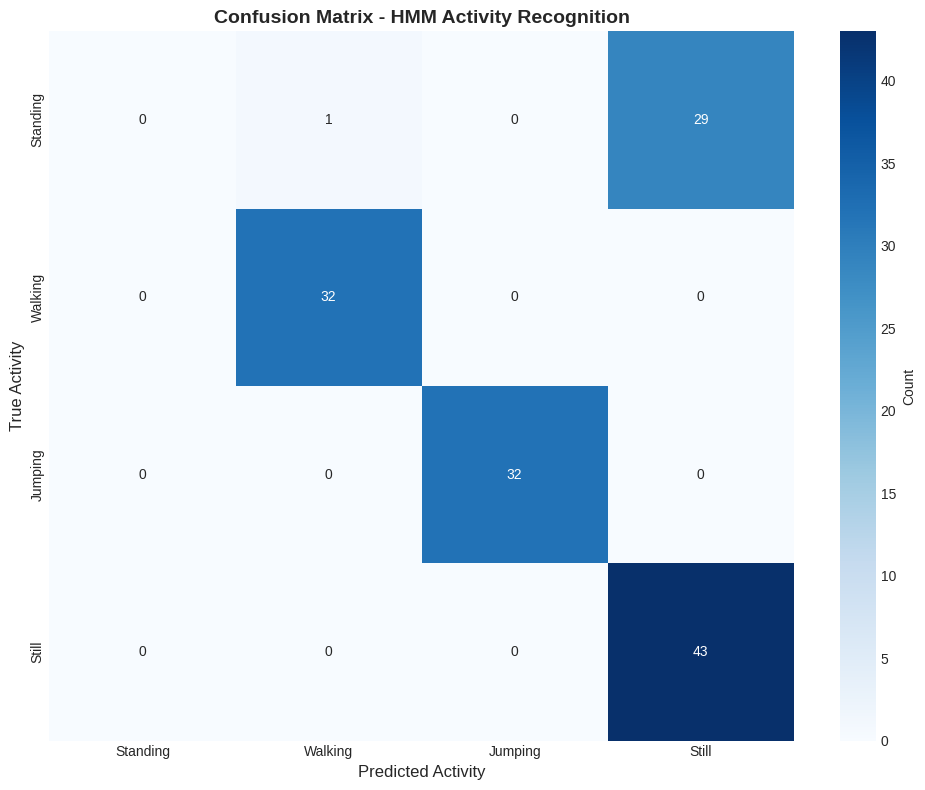

In [33]:
# Visualize confusion matrix
cm = confusion_matrix(y_test, y_pred_mapped)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - HMM Activity Recognition', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Activity', fontsize=12)
plt.ylabel('True Activity', fontsize=12)
plt.tight_layout()
plt.show()

This table shows the confusion matrix for the HMM predictions:

* Rows (True): The actual activity labels.

* Columns (Predicted): The activity labels predicted by the HMM.

Each cell shows the number of windows classified for that true–predicted pair.

From the matrix:

* Standing: Most windows were misclassified as Still (29 out of 30).

* Walking: Perfectly predicted (32/32).

* Jumping: Perfectly predicted (32/32).

* Still: Perfectly predicted (43/43).

This confirms that Walking, Jumping, and Still are well recognized, while Standing is often confused with Still, likely because their sensor patterns are similar.

In [34]:
# Calculate sensitivity and specificity for each activity
from sklearn.metrics import recall_score, precision_score

print("\nMetrics per Activity:")
print(f"{'Activity':<15} {'Samples':<10} {'Sensitivity':<15} {'Specificity':<15} {'Precision':<15}")

results_table = []

for idx, activity in enumerate(ACTIVITIES):
    # Create binary labels (current activity vs all others)
    y_true_binary = (y_test == idx).astype(int)
    y_pred_binary = (y_pred_mapped == idx).astype(int)

    # Calculate metrics
    n_samples = np.sum(y_true_binary)
    sensitivity = recall_score(y_true_binary, y_pred_binary, zero_division=0)

    # Specificity = TN / (TN + FP)
    tn = np.sum((y_true_binary == 0) & (y_pred_binary == 0))
    fp = np.sum((y_true_binary == 0) & (y_pred_binary == 1))
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)

    print(f"{activity:<15} {n_samples:<10} {sensitivity:<15.4f} {specificity:<15.4f} {precision:<15.4f}")

    results_table.append({
        'Activity': activity,
        'Number of Samples': n_samples,
        'Sensitivity': f"{sensitivity:.4f}",
        'Specificity': f"{specificity:.4f}",
        'Precision': f"{precision:.4f}"
    })

print(f"{'Overall Accuracy':<15} {'':<10} {'':<15} {'':<15} {accuracy:.4f}")

# Save results to DataFrame for the report
results_df = pd.DataFrame(results_table)


Metrics per Activity:
Activity        Samples    Sensitivity     Specificity     Precision      
Standing        30         0.0000          1.0000          0.0000         
Walking         32         1.0000          0.9905          0.9697         
Jumping         32         1.0000          1.0000          1.0000         
Still           43         1.0000          0.6915          0.5972         
Overall Accuracy                                            0.7810


This code calculates sensitivity, specificity, and precision for each activity:

* Sensitivity (Recall): How well the model identifies true positives for that activity.

* Specificity: How well the model correctly identifies negatives (windows that are not the activity).

* Precision: Fraction of predicted windows for an activity that were correct.

* Samples: Number of test windows for each activity.

From the results:

* Standing: Sensitivity and precision are 0 → most standing windows were misclassified.

* Walking and Jumping: Perfect or near-perfect sensitivity and specificity.

* Still: High sensitivity (all Still windows identified) but lower specificity and precision (some other activities misclassified as Still).

Overall Accuracy: 78.1%, reflecting the model’s general performance across all activities.

In [35]:
results_df

,Activity,Number of Samples,Sensitivity,Specificity,Precision
0,Standing,30,0.0000,1.0000,0.0000
1,Walking,32,1.0000,0.9905,0.9697
2,Jumping,32,1.0000,1.0000,1.0000
3,Still,43,1.0000,0.6915,0.5972


## Visualize Decoded Sequences

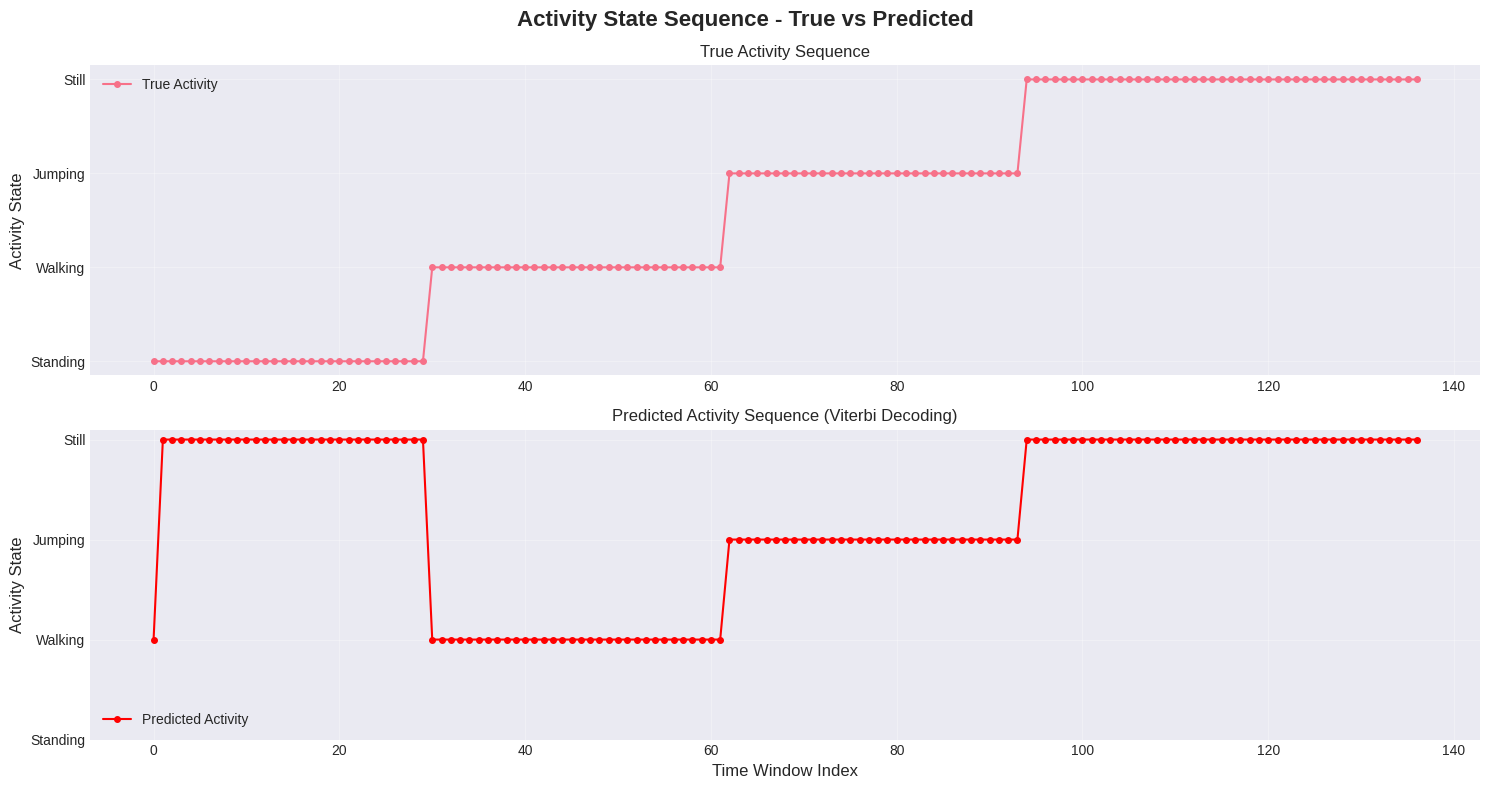

In [36]:
# Plot predicted vs true activity sequences for a sample
sample_length = min(200, len(y_test))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))
fig.suptitle('Activity State Sequence - True vs Predicted', fontsize=16, fontweight='bold')

# True sequence
ax1.plot(range(sample_length), y_test[:sample_length], 'o-', label='True Activity', markersize=4)
ax1.set_ylabel('Activity State', fontsize=12)
ax1.set_yticks(range(N_STATES))
ax1.set_yticklabels(ACTIVITIES)
ax1.set_title('True Activity Sequence')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Predicted sequence
ax2.plot(range(sample_length), y_pred_mapped[:sample_length], 'o-',
         label='Predicted Activity', color='red', markersize=4)
ax2.set_xlabel('Time Window Index', fontsize=12)
ax2.set_ylabel('Activity State', fontsize=12)
ax2.set_yticks(range(N_STATES))
ax2.set_yticklabels(ACTIVITIES)
ax2.set_title('Predicted Activity Sequence (Viterbi Decoding)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

This plot compares the true activity sequence with the HMM-predicted sequence for a sample of the test data:

Top plot: Shows the actual activity states (y_test) over consecutive windows.

Bottom plot: Shows the predicted activity states (y_pred_mapped) obtained via Viterbi decoding of the HMM.

Each point represents a time window.

Insights:

High-movement activities like Walking and Jumping are predicted accurately.

Low-movement activities (Standing vs Still) are sometimes confused, which matches the sensitivity and confusion matrix results.

This visualization helps identify where misclassifications occur over time and shows the temporal consistency of the HMM predictions.

In [37]:
print("ANALYSIS AND INSIGHTS")

print("\n1. ACTIVITY DISTINGUISHABILITY:")

# Analyze which activities are easiest/hardest to distinguish
from sklearn.metrics import f1_score

for idx, activity in enumerate(ACTIVITIES):
    y_true_binary = (y_test == idx).astype(int)
    y_pred_binary = (y_pred_mapped == idx).astype(int)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    print(f"  {activity.capitalize():<15} F1-Score: {f1:.4f}")

print("\n2. TRANSITION PROBABILITY INSIGHTS:")
print("Most likely transitions:")
for i, from_activity in enumerate(ACTIVITIES):
    for j, to_activity in enumerate(ACTIVITIES):
        if model.transmat_[i, j] > 0.3 and i != j:
            print(f"  {from_activity} → {to_activity}: {model.transmat_[i, j]:.4f}")

print("\n3. COMMON MISCLASSIFICATIONS:")
for i in range(N_STATES):
    for j in range(N_STATES):
        if i != j and cm[i, j] > 0:
            error_rate = cm[i, j] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
            if error_rate > 0.1:  # Show if >10% error
                print(f"  {ACTIVITIES[i]} misclassified as {ACTIVITIES[j]}: "
                      f"{cm[i, j]} times ({error_rate*100:.1f}%)")

print("\n4. MODEL PERFORMANCE SUMMARY:")
print(f"  Overall Accuracy: {accuracy*100:.2f}%")
print(f"  Number of States: {N_STATES}")
print(f"  Number of Features: {X_train_scaled.shape[1]}")
print(f"  Training Samples: {len(X_train)}")
print(f"  Test Samples: {len(X_test)}")

ANALYSIS AND INSIGHTS

1. ACTIVITY DISTINGUISHABILITY:
  Standing        F1-Score: 0.0000
  Walking         F1-Score: 0.9846
  Jumping         F1-Score: 1.0000
  Still           F1-Score: 0.7478

2. TRANSITION PROBABILITY INSIGHTS:
Most likely transitions:

3. COMMON MISCLASSIFICATIONS:
  Standing misclassified as Still: 29 times (96.7%)

4. MODEL PERFORMANCE SUMMARY:
  Overall Accuracy: 78.10%
  Number of States: 4
  Number of Features: 83
  Training Samples: 426
  Test Samples: 137


Analysis and Insights:

1. Activity Distinguishability:

    * F1-scores show how easily each activity is detected:

        * Walking and Jumping are very easy to identify (F1 ≈ 1.0).

        * Still is moderately distinguishable (F1 ≈ 0.75).

        * Standing is very hard to distinguish (F1 = 0), often misclassified as Still.

2. Transition Probability Insights:

    * The model’s transition matrix shows probabilities of switching from one activity to another.

    * No high (>0.3) transitions between different activities were observed, indicating that the model mostly predicts consecutive windows as the same activity.

3. Common Misclassifications:

    * Standing is the activity most frequently misclassified, almost always predicted as Still (96.7%).

    * Other activities are generally well recognized.

4. Model Performance Summary:

    * Overall Accuracy: 78.1%

    * Hidden States: 4 (one per activity)

    * Features used: 83

    * Training Samples: 426, Test Samples: 137

Insight: The HMM effectively distinguishes high-movement activities (Walking, Jumping), but low-movement activities like Standing and Still are harder to separate due to similar sensor patterns. Improving feature selection or adding more sensors could help reduce confusion between these states.

In [38]:
# Create a summary report
summary = {
    'Overall Accuracy': f"{accuracy:.4f}",
    'Number of States': N_STATES,
    'Number of Features': X_train_scaled.shape[1],
    'Training Samples': len(X_train),
    'Test Samples': len(X_test),
    'Activities': ACTIVITIES,
    'Sampling Rate': '100 Hz',
    'Window Size': 100,
    'Window Overlap': 0.5
}

summary_df = pd.DataFrame([summary])
summary_df

,Overall Accuracy,Number of States,Number of Features,Training Samples,Test Samples,Activities,Sampling Rate,Window Size,Window Overlap
0,0.7810,4,83,426,137,"[Standing, Walking, Jumping, Still]",100 Hz,100,0.5
